In [1]:
import sys
sys.path.append(r'C:\Users\13262\Desktop\ANALYSIS_SCRIPT')

from data_processor import (
    load_all_data,
    extract_reading_tasks,
    extract_writing_nl_tasks,
    extract_modifying_tasks,
    extract_writing_tasks,
    aggregate_tasks_with_format,
    extract_post_task_questions,
    analyze_nasa_and_post_surveys,
    melt_tlx,
    aggregate_quiz_parts,
    summarize_quiz_parts,
    evaluate_quiz_answers_from_tutorial,
    extract_and_encode_familiarity,
    get_answer_counts,
    plot_answer_distribution,
    extract_survey_items,
    extract_post_task_tlx_responses,
    merge_dfs
)

from time_analysis import (
    time_analysis,
    normalize_typing_time,
    compute_task_time_ratio,
    get_task_group,
    compute_avg_ratio,
    plot_stacked_ratio
)



from statistic import (
    compare_statistically,
    vis_violin_comparison,
    compare_significant_pairs,
    vis_box_comparasion,
    vis_raincloud,
    vis_raincloud_by_task,
    vis_discrete_heatmap_comparison_by_task,
    vis_discrete_heatmap_comparison)

from correctness_analysis import (
    annotate_reading_correctness_exact,
    visualize_accuracy_heatmap,
    visualize_score_distribution_heatmap,
    plot_binary_response_vs_metric_heatmap,
    plot_nasatlx_correct,
    plot_time_vs_response_heatmap,
    plot_duration_vs_correct_with_stats
)


from format_check import (
    process_dataframe_with_validation,
    add_overall_rows)


In [2]:

import pandas as pd 
import os

file_path_1 = os.path.join('DATA', 'df_ratio_writing_tabular.csv')
df_tabular= pd.read_csv(file_path_1)

file_path_2 = os.path.join('DATA', 'df_ratio_writing_config.csv')
df_config= pd.read_csv(file_path_2)

df_combined = pd.concat([df_tabular, df_config], axis=0, ignore_index=True)
df_combined


,participantId,format,task_time,total_time,ratio,task
0,56cb8858edf8da000b6df354,hjson,261.300,1651.244,0.158244,writing_time/total_time
1,57c357770e6a1f00015f6038,json,604.521,1920.530,0.314768,writing_time/total_time
2,5b68c9eb87af310001584803,json5,280.880,1486.117,0.189003,writing_time/total_time
3,5c6414540821d30001046198,hjson,1302.003,4168.250,0.312362,writing_time/total_time
4,5d30dfa68b1523000134878f,json,587.347,2678.738,0.219263,writing_time/total_time
...,...,...,...,...,...,...
209,67f66486e35051403284eb5e,xml,650.273,5137.755,0.126568,writing_time/total_time
210,680ebf035ab59d342f31726e,hjson,1309.504,5409.048,0.242095,writing_time/total_time
211,681374d36d7bd7ccb6f914f5,json5,333.673,1645.962,0.202722,writing_time/total_time
212,68138e7f96395f4c5f3a0a87,json,703.515,5339.368,0.131760,writing_time/total_time


In [4]:

import pandas as pd 
import os

file_path_1 = os.path.join('DATA', 'df_quiz_summary_tabular.csv')
df_tabular= pd.read_csv(file_path_1)

file_path_2 = os.path.join('DATA', 'df_quiz_summary_config.csv')
df_config= pd.read_csv(file_path_2)

df_combined = pd.concat([df_tabular, df_config], axis=0, ignore_index=True)
df_combined

,participantId,format,quiz_key,num_wrong_attempts,wrong_choice_count,correct,task
0,56cb8858edf8da000b6df354,hjson,tutorial-hjson,0,0,1.0,tutorial_quiz
1,57c357770e6a1f00015f6038,json,tutorial-json,1,1,1.0,tutorial_quiz
2,5b68c9eb87af310001584803,json5,tutorial-json5,3,2,1.0,tutorial_quiz
3,5c6414540821d30001046198,hjson,tutorial-hjson,2,0,1.0,tutorial_quiz
4,5d30dfa68b1523000134878f,json,tutorial-json,3,6,1.0,tutorial_quiz
...,...,...,...,...,...,...,...
209,67f66486e35051403284eb5e,xml,tutorial-xml,3,3,1.0,tutorial_quiz
210,680ebf035ab59d342f31726e,hjson,tutorial-hjson,6,0,0.5,tutorial_quiz
211,681374d36d7bd7ccb6f914f5,json5,tutorial-json5,4,5,1.0,tutorial_quiz
212,68138e7f96395f4c5f3a0a87,json,tutorial-json,3,7,1.0,tutorial_quiz


In [ ]:
import os

os.makedirs('DATA', exist_ok=True)

# 2. 保存为 CSV 文件
df_quiz_summary.to_csv('DATA/df_quiz_summary_config.csv', index=False)

In [10]:
import pandas as pd 
import os

file_path_1 = os.path.join('DATA', 'df_nasa_tidy_tabular.csv')
df_tabular= pd.read_csv(file_path_1)

file_path_2 = os.path.join('DATA', 'df_nasa_tidy_config.csv')
df_config= pd.read_csv(file_path_2)

df_combined = pd.concat([df_tabular, df_config], axis=0, ignore_index=True)
df_combined

,participantId,format,startTime,endTime,duration_sec,task,score
0,56cb8858edf8da000b6df354,hjson,1746392601041,1746392648555,47.514,mental-demand,30
1,57c357770e6a1f00015f6038,json,1746385108000,1746385128866,20.866,mental-demand,100
2,5b68c9eb87af310001584803,json5,1746384720007,1746384734537,14.530,mental-demand,95
3,5c6414540821d30001046198,hjson,1747344100433,1747344133058,32.625,mental-demand,98
4,5d30dfa68b1523000134878f,json,1745931232960,1745931258924,25.964,mental-demand,96
...,...,...,...,...,...,...,...
1279,67f66486e35051403284eb5e,xml,1746774574948,1746774650954,76.006,frustration,52
1280,680ebf035ab59d342f31726e,hjson,1747177786428,1747177845239,58.811,frustration,70
1281,681374d36d7bd7ccb6f914f5,json5,1747342678902,1747342696386,17.484,frustration,0
1282,68138e7f96395f4c5f3a0a87,json,1746780893010,1746780920405,27.395,frustration,100


c:\Users\13262\Desktop\analysis_script\statistic\__init__.py:791: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf[group_col] = pd.Categorical(subdf[group_col], categories=order, ordered=True)
c:\Users\13262\anaconda3\Lib\site-packages\seaborn\categorical.py:1296: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\13262\anaconda3\Lib\site-packages\seaborn\categorical.py:1296: UserWarning: 10.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


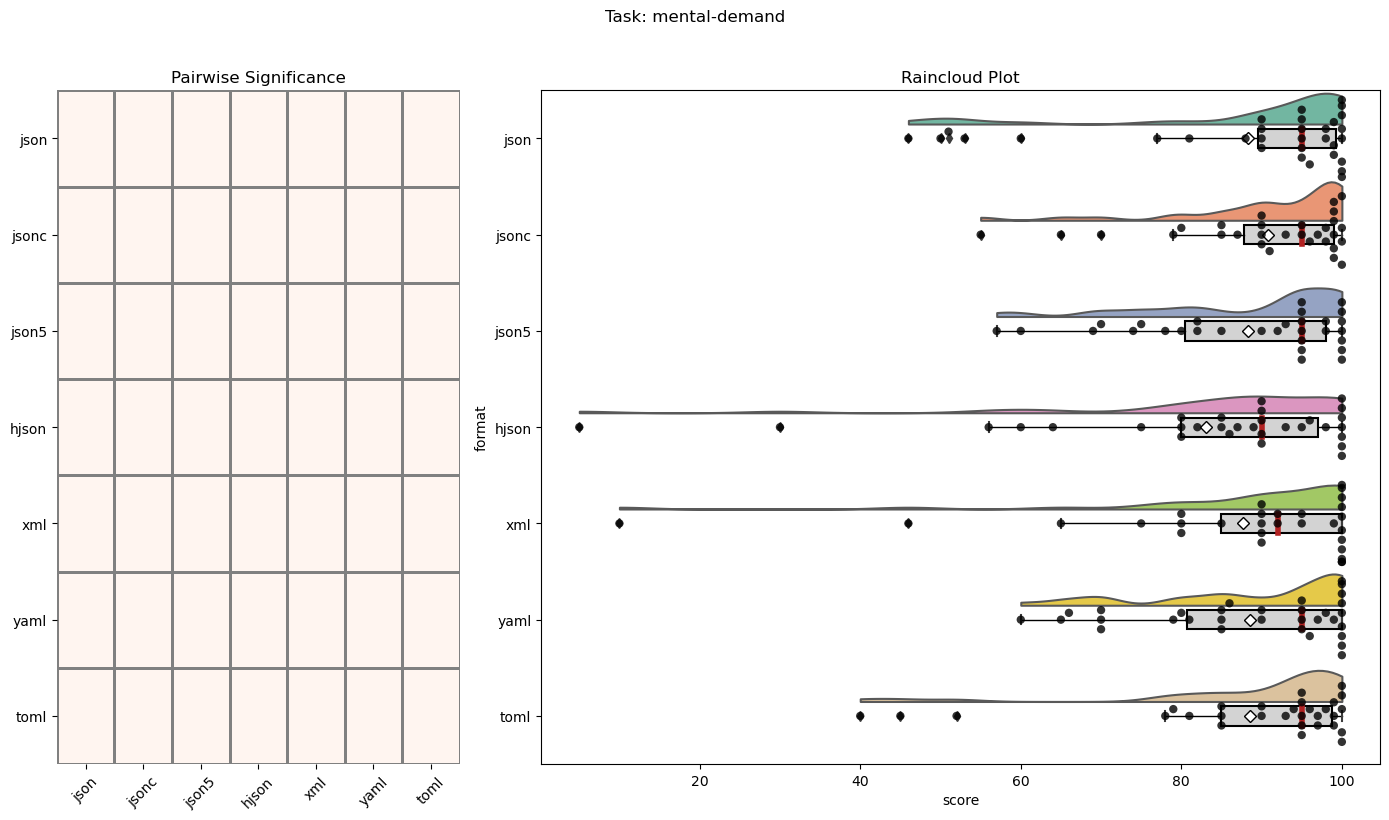

c:\Users\13262\Desktop\analysis_script\statistic\__init__.py:791: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf[group_col] = pd.Categorical(subdf[group_col], categories=order, ordered=True)


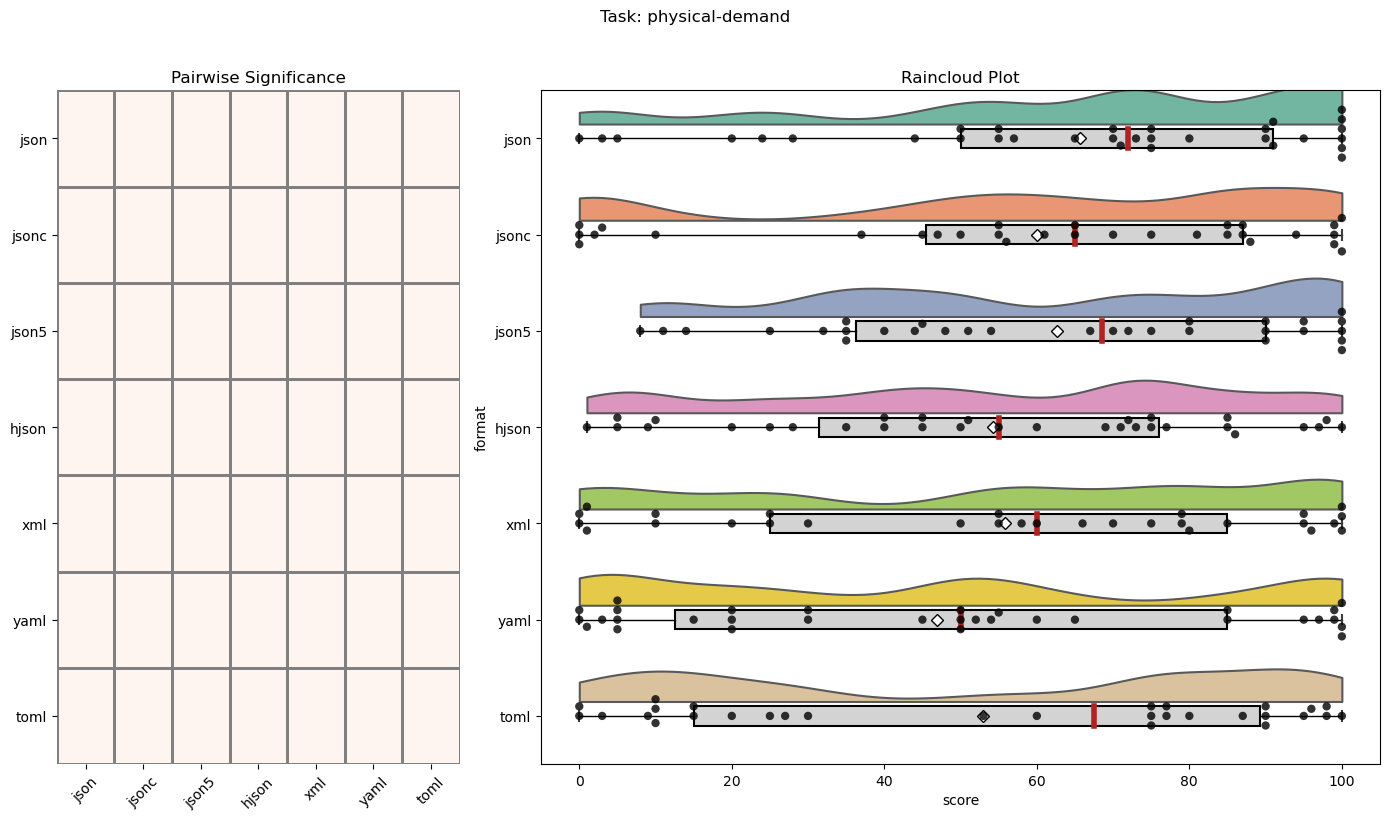

c:\Users\13262\Desktop\analysis_script\statistic\__init__.py:791: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf[group_col] = pd.Categorical(subdf[group_col], categories=order, ordered=True)


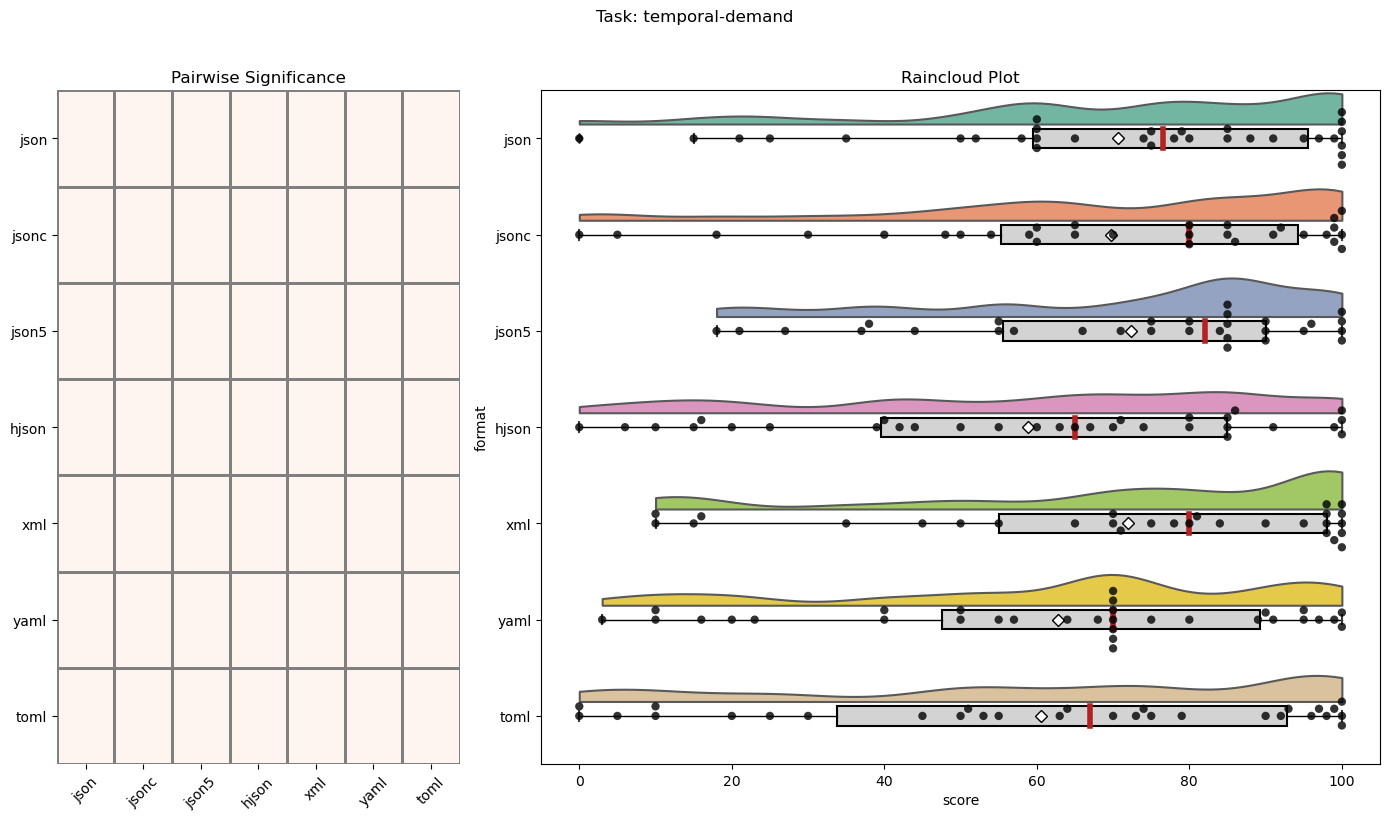

c:\Users\13262\Desktop\analysis_script\statistic\__init__.py:791: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf[group_col] = pd.Categorical(subdf[group_col], categories=order, ordered=True)


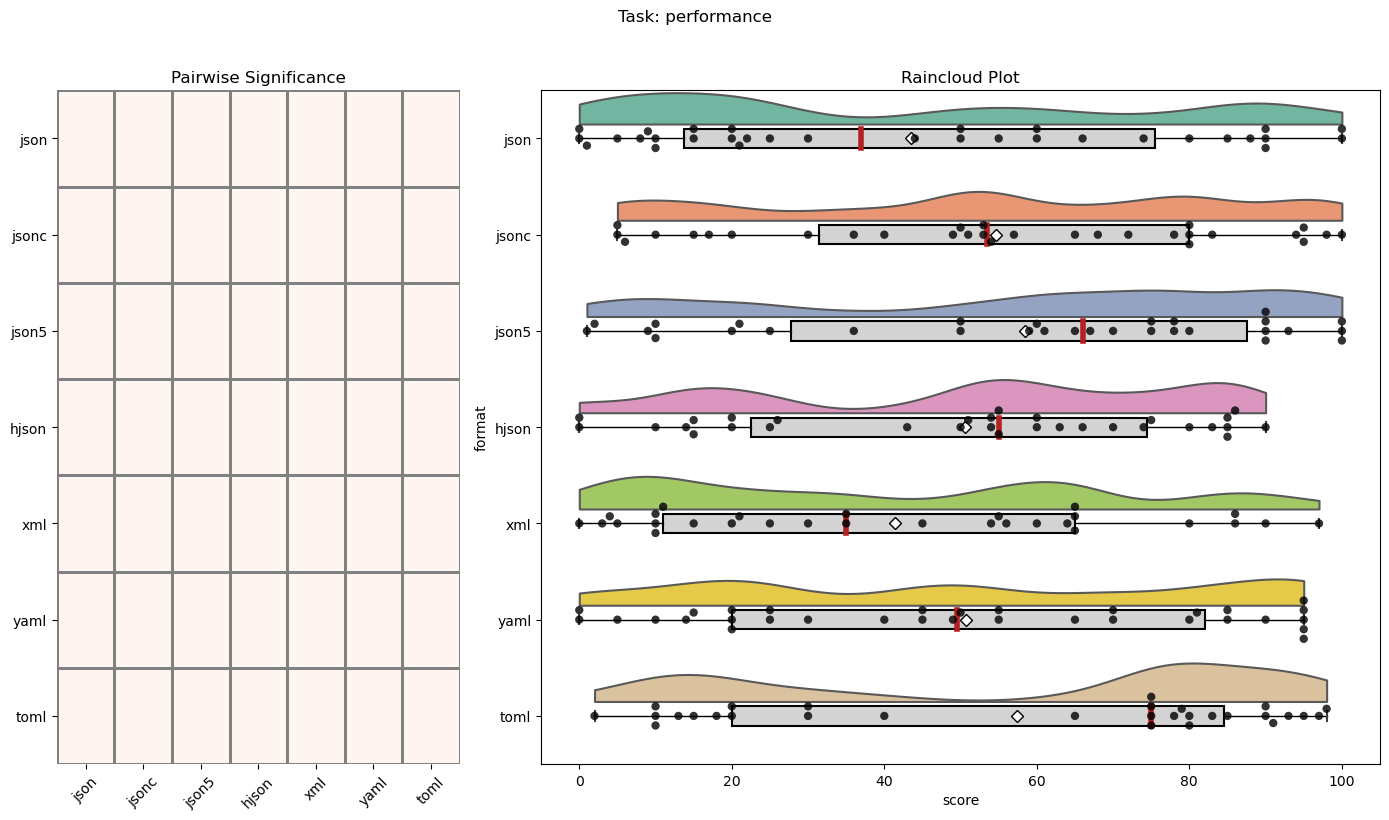

c:\Users\13262\Desktop\analysis_script\statistic\__init__.py:791: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf[group_col] = pd.Categorical(subdf[group_col], categories=order, ordered=True)
c:\Users\13262\anaconda3\Lib\site-packages\seaborn\categorical.py:1296: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


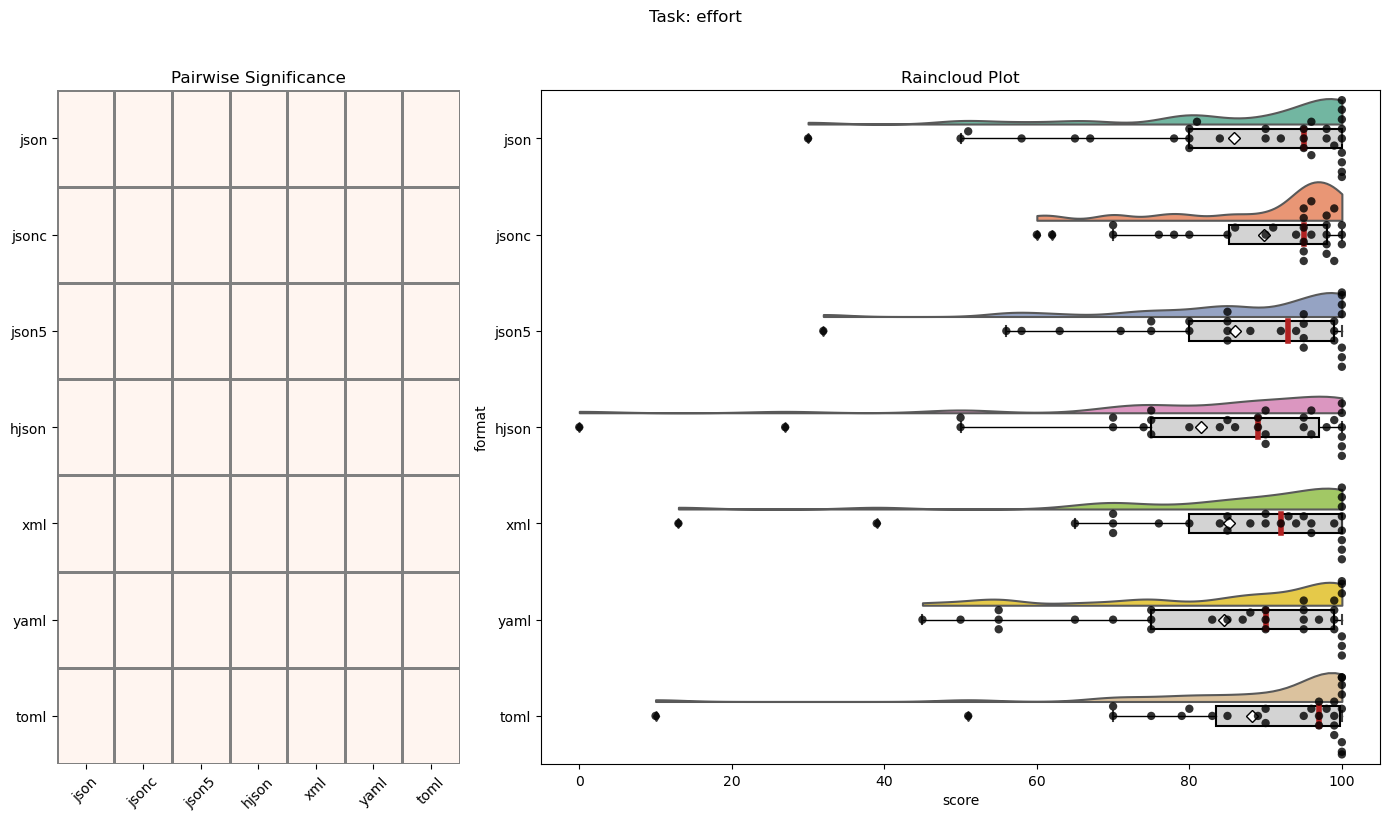

c:\Users\13262\Desktop\analysis_script\statistic\__init__.py:791: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf[group_col] = pd.Categorical(subdf[group_col], categories=order, ordered=True)


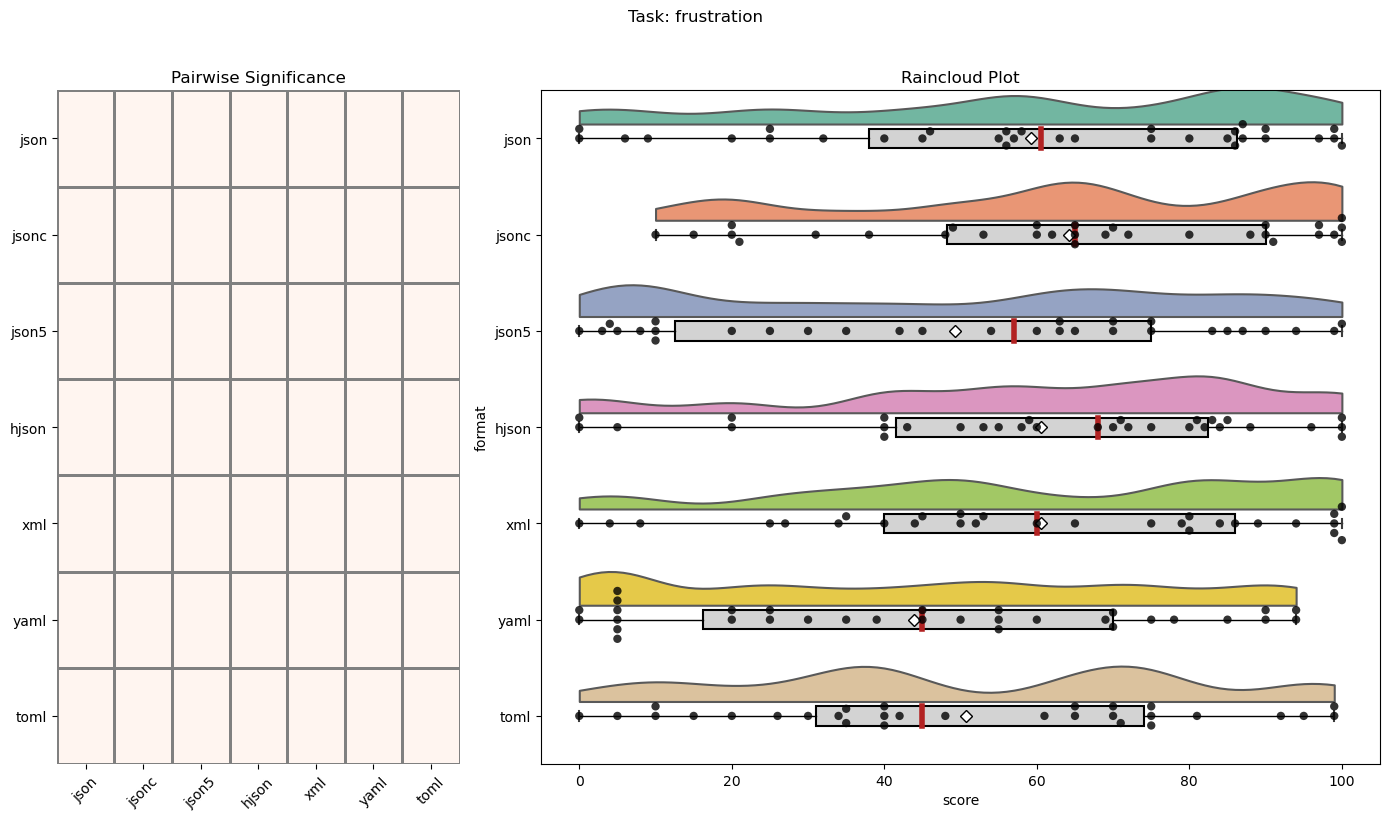

In [11]:
vis_raincloud_by_task(
    df_combined,
    group_col='format',
    value_col='score',
    task_col='task',      # 这里填你的任务列名
    method='anova',
    show_significance=True,
    palette_name='Set2'
)

In [12]:
file_path_1 = os.path.join('DATA', 'df_reading_agg_overall_tabular.csv')
df_tabular= pd.read_csv(file_path_1)

file_path_2 = os.path.join('DATA', 'df_reading_agg_overall_config.csv')
df_config= pd.read_csv(file_path_2)

df_reading_agg_overall = pd.concat([df_tabular, df_config], axis=0, ignore_index=True)

In [13]:
file_path_1 = os.path.join('DATA', 'df_nasa_tabular.csv')
df_tabular= pd.read_csv(file_path_1)

file_path_2 = os.path.join('DATA', 'df_nasa_config.csv')
df_config= pd.read_csv(file_path_2)

df_nasa = pd.concat([df_tabular, df_config], axis=0, ignore_index=True)

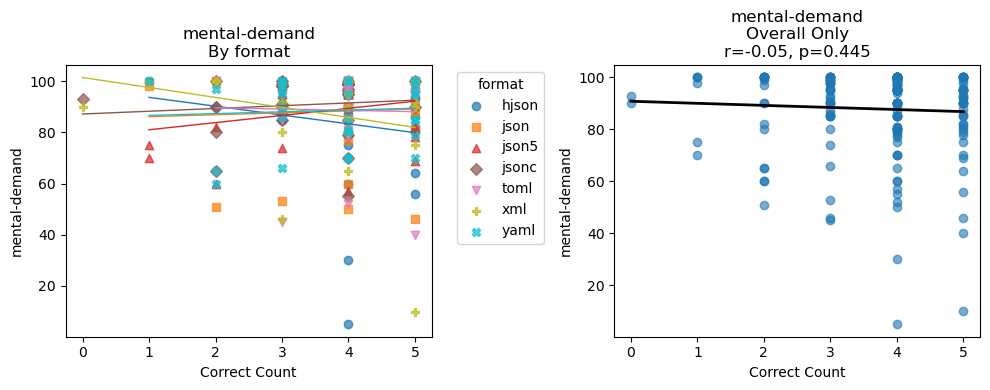

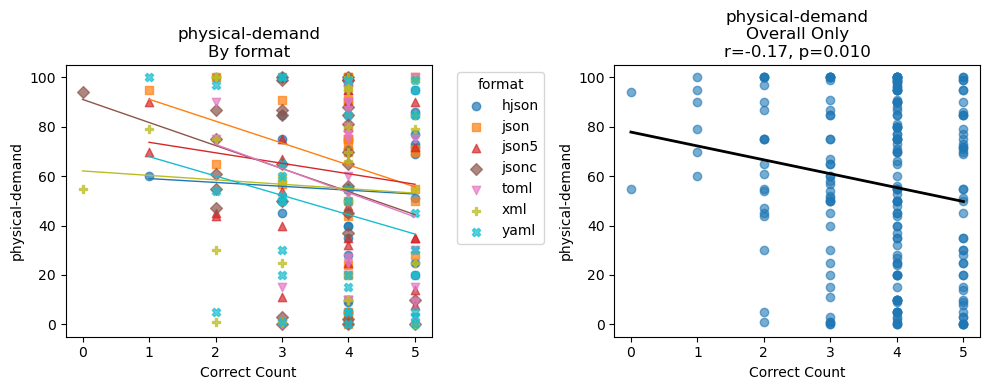

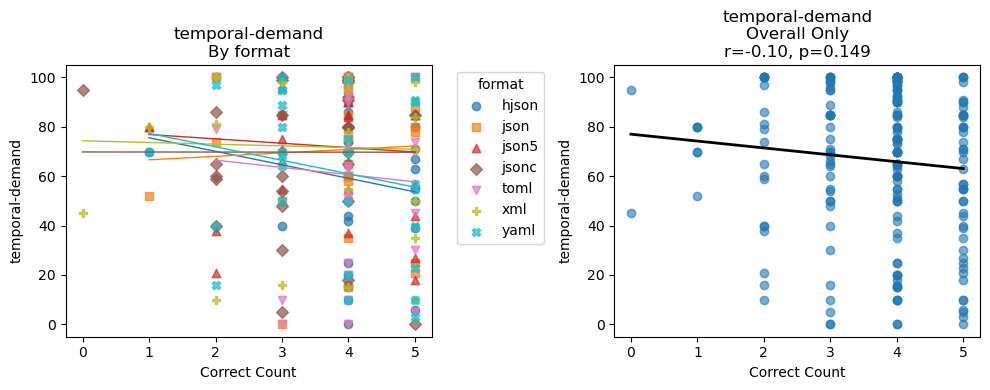

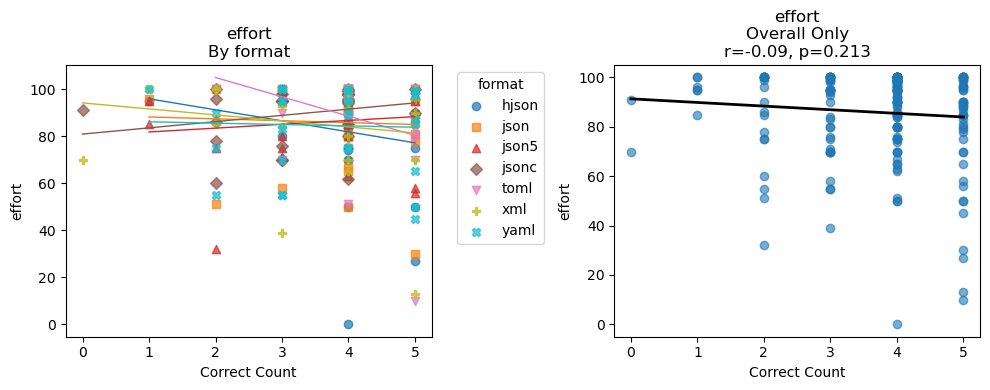

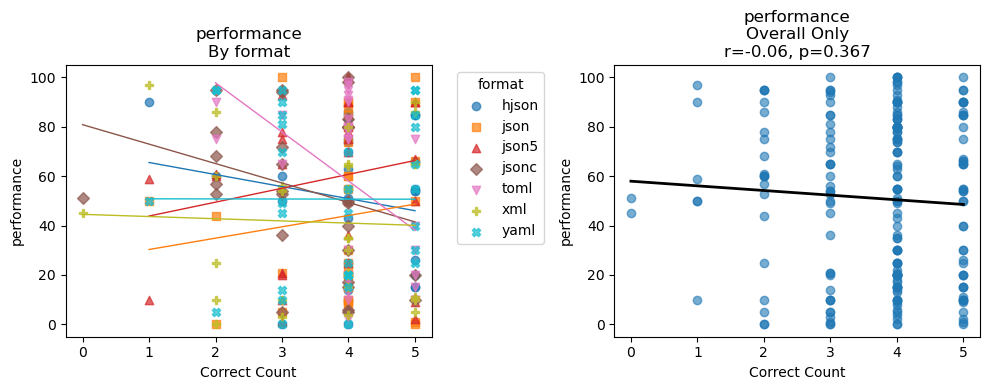

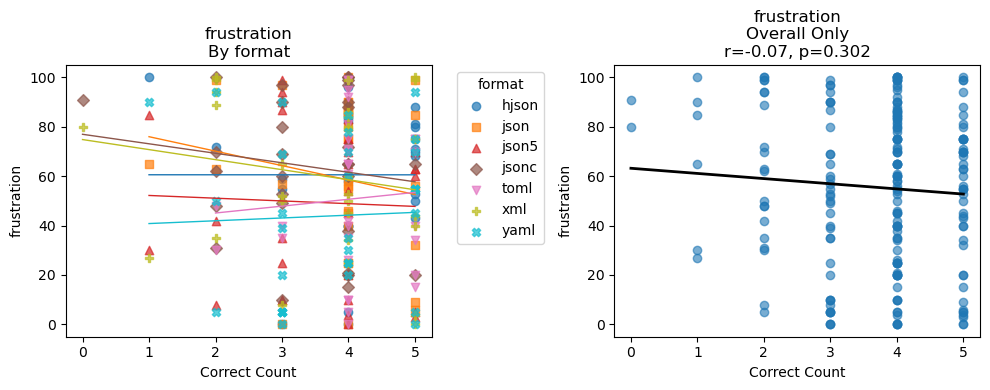

In [15]:
plot_nasatlx_correct(
    df_reading         = df_reading_agg_overall,
    df_nasa            = df_nasa,
    metrics            = ['mental-demand','physical-demand','temporal-demand','effort','performance','frustration'],
    group_col          = 'format',
    agg_func           = 'mean',
    show_by_format     = True,   
    show_overall       = True,  
    show_residual      = False,   
    show_overall_trend = False,  
    figsize_per        = (5,4)
)

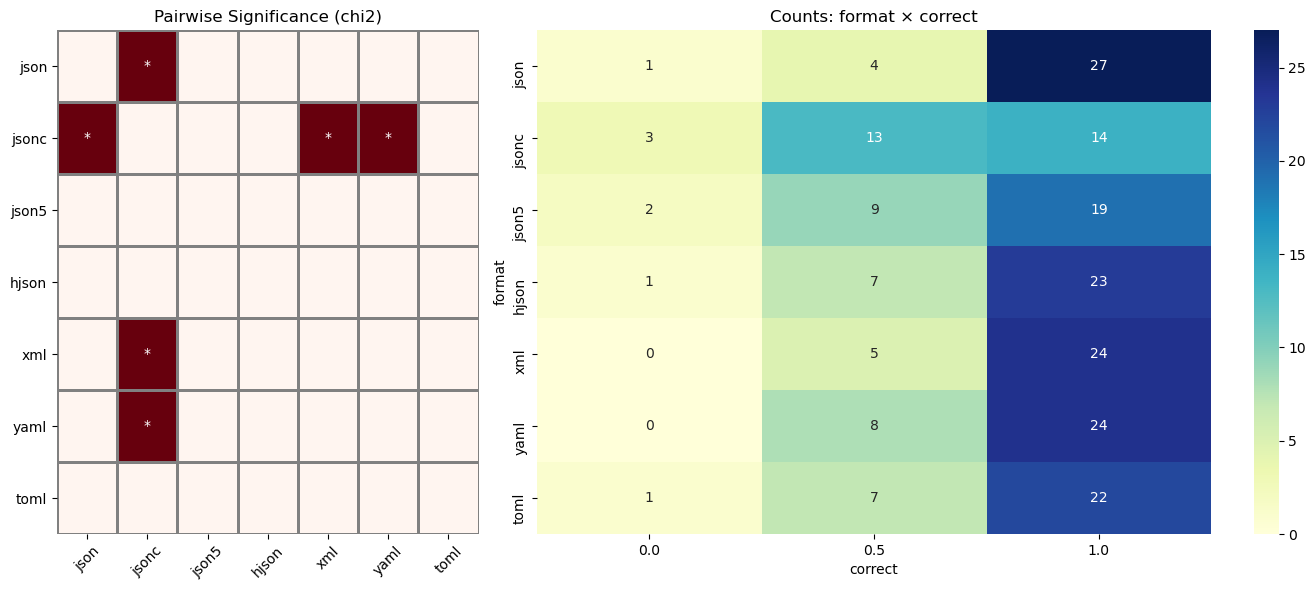

In [5]:
vis_discrete_heatmap_comparison_by_task(
    df_combined,
    group_col='format',
    value_col='correct',
    method='chi2',
    task_col='task',
    palette_name='YlGnBu',
    alpha=0.05
)

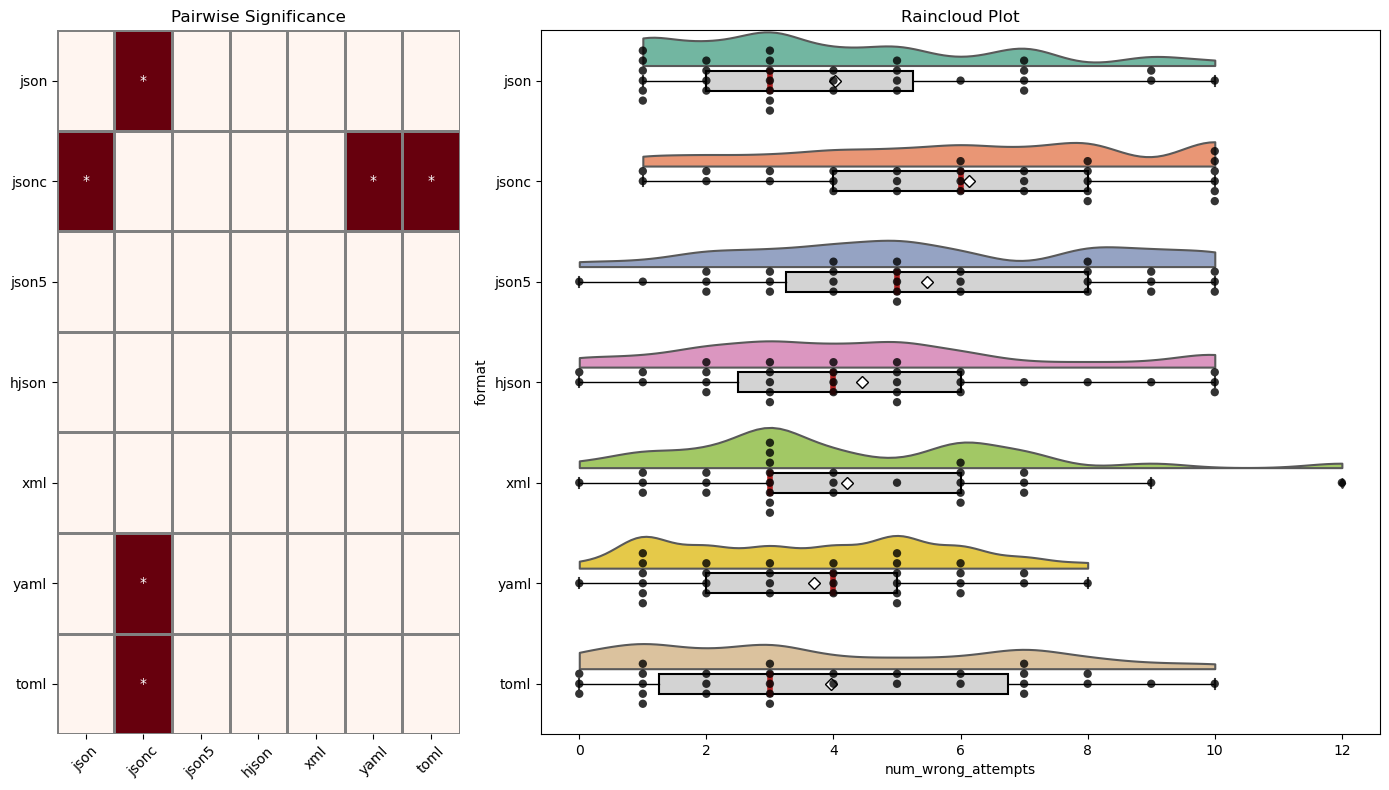

In [8]:
vis_raincloud_by_task(
    df_combined,
    group_col='format',
    value_col='num_wrong_attempts',
    task_col='task',      # 这里填你的任务列名
    method='anova',
    show_significance=True,
    palette_name='Set2'
)

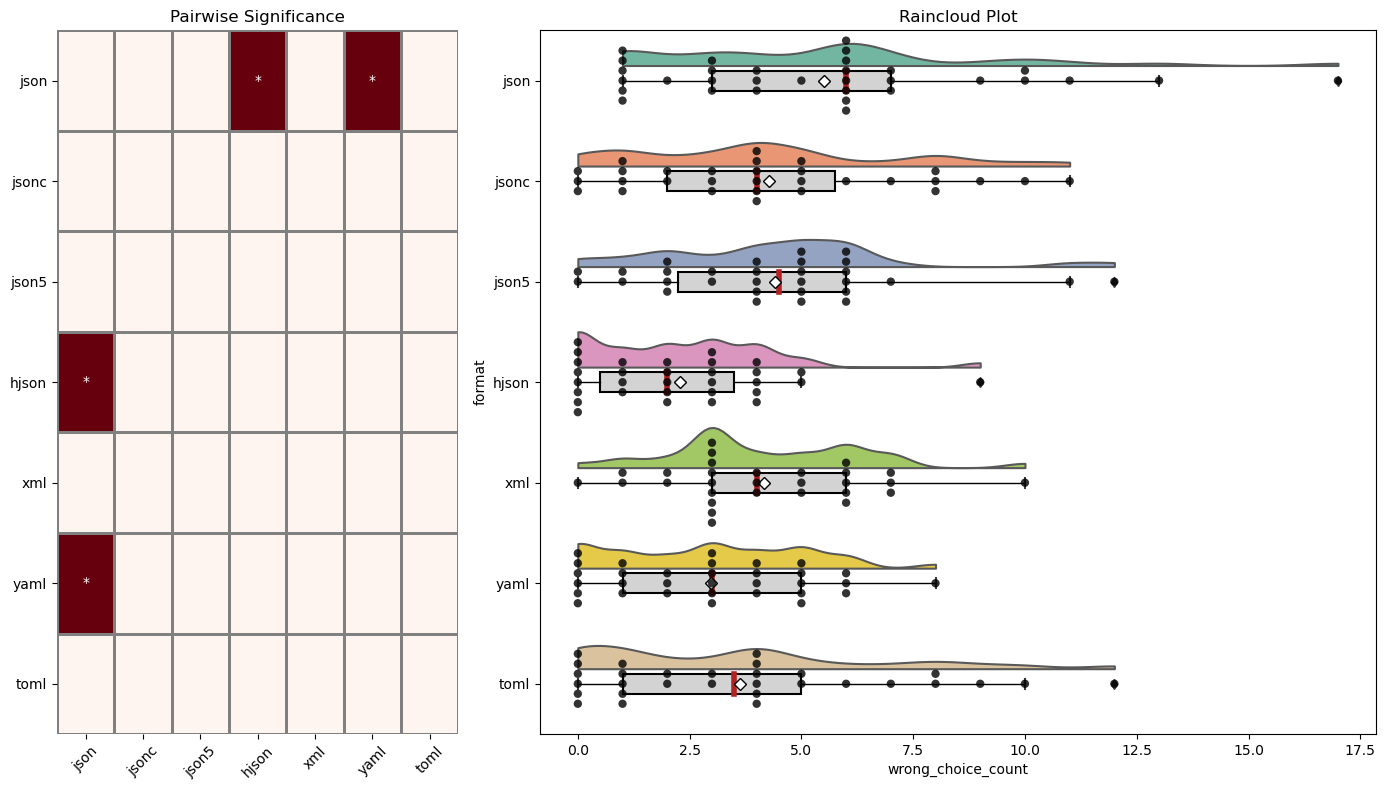

In [9]:
vis_raincloud_by_task(
    df_combined,
    group_col='format',
    value_col='wrong_choice_count',
    task_col='task',      # 这里填你的任务列名
    method='anova',
    show_significance=True,
    palette_name='Set2'
)

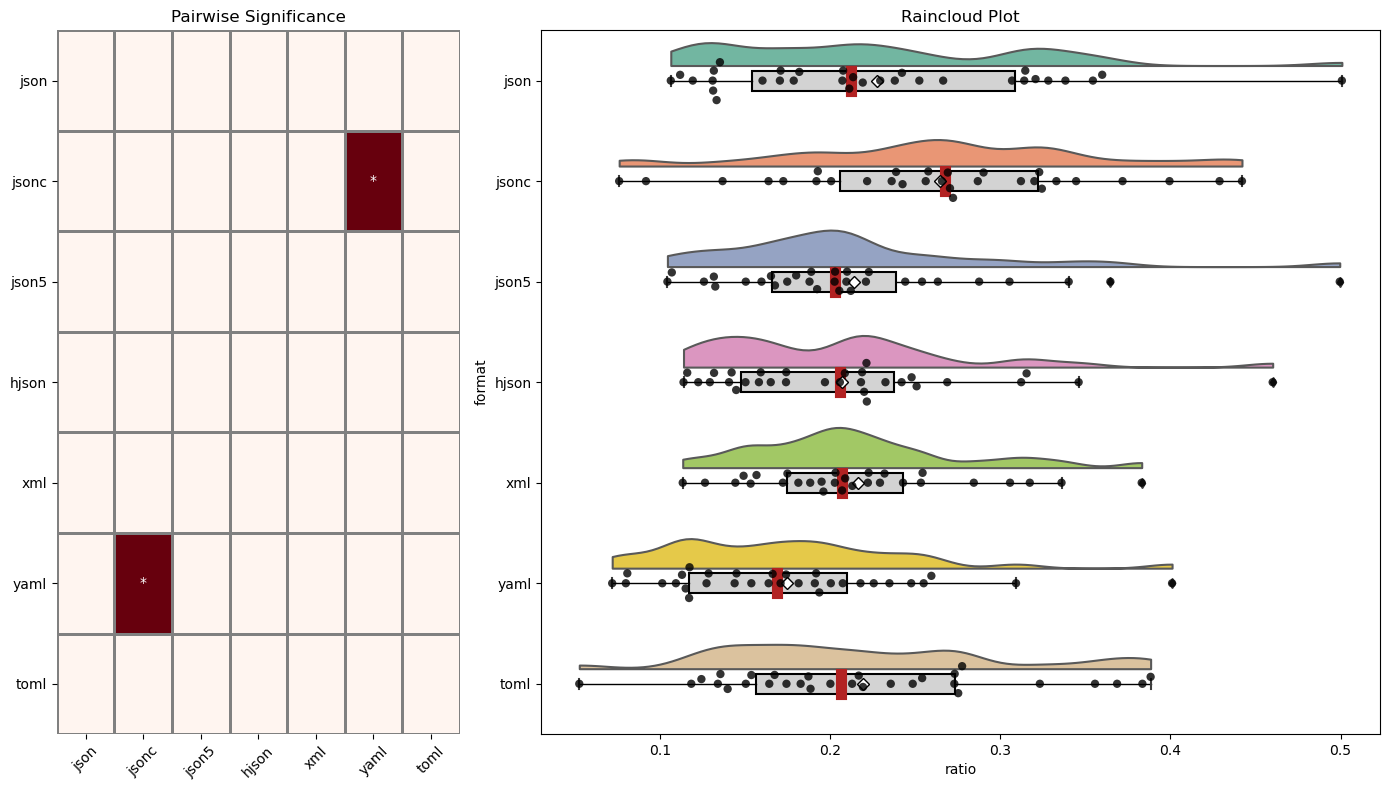

In [3]:
vis_raincloud(
    df=df_combined,
    group_col='format',
    value_col='ratio',
    method='anova',
    show_significance=True,
    palette_name='Set2'
)

In [ ]:
vis_discrete_heatmap_comparison_by_task(
    df_reading_agg,
    group_col='format',
    value_col='correct',
    method='chi2',
    task_col='task',
    palette_name='YlGnBu',
    alpha=0.05
)


vis_raincloud_by_task(
    df_reading_clean,
    group_col='format',
    value_col='duration_sec',
    task_col='task',      # 这里填你的任务列名
    method='anova',
    show_significance=True,
    palette_name='Set2'
)

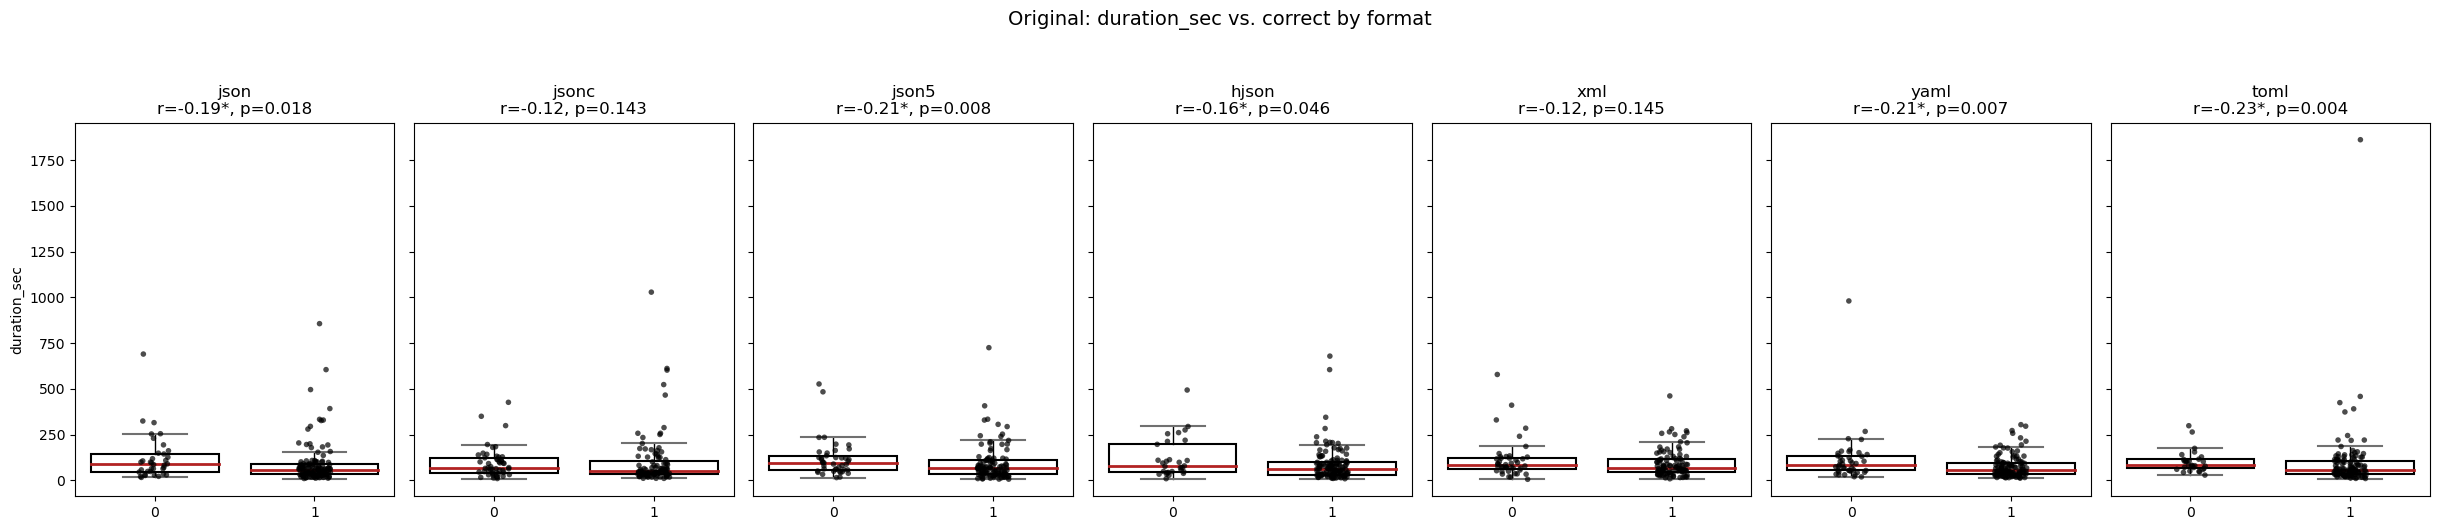

In [ ]:
import pandas as pd 
import os

file_path_1 = os.path.join('DATA', 'df_reading_result_tabular.csv')
df_tabular= pd.read_csv(file_path_1)

file_path_2 = os.path.join('DATA', 'df_reading_result_config.csv')
df_config= pd.read_csv(file_path_2)

df_reading_result = pd.concat([df_tabular, df_config], axis=0, ignore_index=True)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def visualize_original_duration_vs_correct_by_format(
    df,
    format_col: str = 'format',
    duration_col: str = 'duration_sec',
    correct_col: str = 'correct',
    order: list = ['json','jsonc','json5','hjson','xml','yaml','toml'],
    alpha: float = 0.05
):
    """
    按 format 分面画原始数据的 duration_sec vs correct：
      - 强制 order=[0,1] 保证两个位置都显示
      - 0/1 对应箱线图 + 抖动散点
      - 每个子图标题标注 Spearman r 和 p（显著时加 *）
      - 按传入 order 保证子图顺序一致
    """
    # 只留 order 中出现的 formats
    formats = [f for f in order if f in df[format_col].unique()]
    if not formats:
        raise ValueError("没有可视化的 format，请检查 order 参数或数据中的 format 列。")
    n = len(formats)

    fig, axes = plt.subplots(1, n, figsize=(n*3.5, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, fmt in zip(axes, formats):
        sub = df[df[format_col] == fmt]
        # Spearman
        if sub[correct_col].nunique() > 1:
            r, p = spearmanr(sub[duration_col], sub[correct_col])
        else:
            r, p = np.nan, np.nan

        # 箱线（加 order=[0,1]）
        sns.boxplot(
            x=correct_col, y=duration_col, data=sub,
            order=[0, 1],
            ax=ax,
            showcaps=True,
            boxprops={'facecolor':'white','edgecolor':'black'},
            whiskerprops={'color':'black','linewidth':1},
            medianprops={'color':'firebrick','linewidth':2},
            showfliers=False,
            palette=['#DDDDDD','#BBBBBB']
        )
        # 散点（同 order）
        sns.stripplot(
            x=correct_col, y=duration_col, data=sub,
            order=[0, 1],
            ax=ax,
            color='black', size=4, jitter=True, alpha=0.7, zorder=5
        )

        star = '*' if (not np.isnan(p) and p < alpha) else ''
        ax.set_title(f"{fmt}\nr={r:.2f}{star}, p={p:.3f}")
        ax.set_xlabel('')
        ax.set_ylabel(duration_col if fmt == formats[0] else '')

    fig.suptitle("Original: duration_sec vs. correct by format", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_original_duration_vs_correct_by_format(
    df_reading_result,
    format_col='format',
    duration_col='duration_sec',
    correct_col='correct',
    order=['json','jsonc','json5','hjson','xml','yaml','toml'],
    alpha=0.05
)

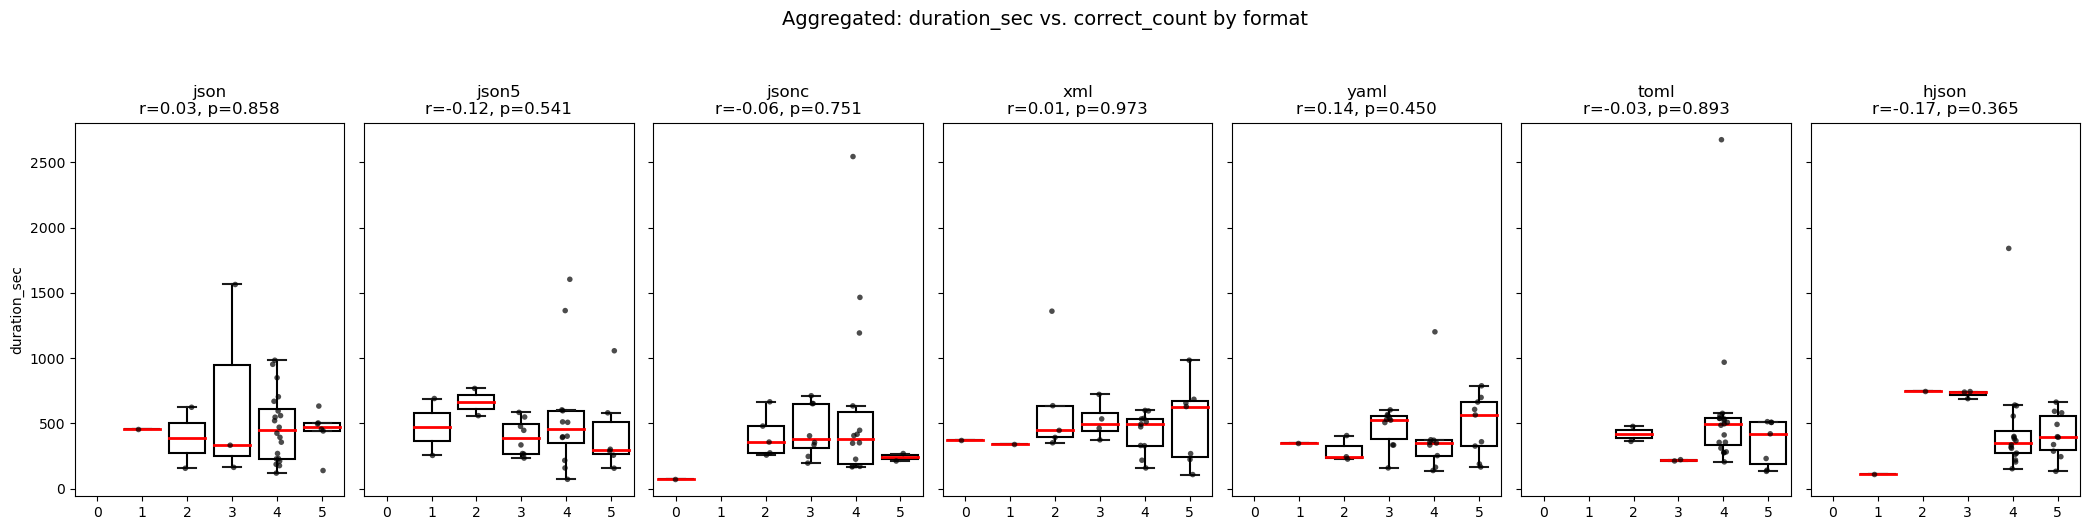

In [21]:
import pandas as pd 
import os

file_path_1 = os.path.join('DATA', 'df_agg_reading_tabular.csv')
df_tabular= pd.read_csv(file_path_1)

file_path_2 = os.path.join('DATA', 'df_agg_reading_config.csv')
df_config= pd.read_csv(file_path_2)

df_agg = pd.concat([df_tabular, df_config], axis=0, ignore_index=True)
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# === 1) 聚合子任务 ===
df = df_reading_result.copy()

# 提取基名（去掉末尾 -数字）
pattern = re.compile(r'(.+)-\d+$')
df['base_task'] = df['task'].astype(str).str.extract(pattern, expand=False)

# 只保留带数字后缀的行
to_agg = df[df['base_task'].notnull()]

# 按 participantId, format, base_task 求和 duration_sec 和 correct
df_agg = (
    to_agg
    .groupby(['participantId', 'format', 'base_task'], as_index=False)
    [['duration_sec', 'correct']]
    .sum()
    .rename(columns={'base_task': 'task'})
)

# === 2) 可视化聚合结果 ===
def visualize_aggregated_duration_vs_correct(
    df_agg: pd.DataFrame,
    format_col: str = 'format',
    duration_col: str = 'duration_sec',
    correct_col: str = 'correct',
    order_formats: list = ['json','json5','jsonc','xml','yaml','toml','hjson'],
    alpha: float = 0.05
):
    """
    按 format 分面画 聚合后的 duration_sec vs. correct_count：
      - 横轴分类为所有出现过的 correct_count 值
      - 箱线 + 抖动散点
      - 标题标注 Spearman r & p（p<alpha 时加 *）
    """
    # 过滤并保持顺序
    df = df_agg[df_agg[format_col].isin(order_formats)].copy()
    formats = [f for f in order_formats if f in df[format_col].unique()]
    n = len(formats)

    # 先找出所有 correct_count 分类
    all_cats = sorted(df[correct_col].unique())

    # 布局：一行 n 子图，共享 y 轴
    fig, axes = plt.subplots(1, n, figsize=(n*3, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, fmt in zip(axes, formats):
        sub = df[df[format_col] == fmt]
        # 相关性
        if sub[correct_col].nunique() > 1:
            r, p = spearmanr(sub[duration_col], sub[correct_col])
        else:
            r, p = np.nan, np.nan

        # 绘箱线：用 all_cats 作为 order
        sns.boxplot(
            x=correct_col, y=duration_col, data=sub,
            order=all_cats,
            ax=ax,
            showcaps=True,
            boxprops={'facecolor':'white','edgecolor':'black'},
            whiskerprops={'color':'black'},
            medianprops={'color':'red','linewidth':2},
            showfliers=False,
            palette='Greys'
        )
        # 绘散点
        sns.stripplot(
            x=correct_col, y=duration_col, data=sub,
            order=all_cats,
            ax=ax,
            color='black', size=4, jitter=True, alpha=0.7, zorder=5
        )

        # 标题
        star = '*' if (not np.isnan(p) and p < alpha) else ''
        ax.set_title(f"{fmt}\nr={r:.2f}{star}, p={p:.3f}")
        ax.set_xlabel('')
        ax.set_ylabel(duration_col if fmt == formats[0] else '')

    plt.suptitle("Aggregated: duration_sec vs. correct_count by format", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

# 最终调用
visualize_aggregated_duration_vs_correct(df_agg)

In [22]:
config=pd.read_csv('a-usability-study-config_all_tidy.csv')
config

,participantId,trialId,trialOrder,responseId,status,rejectReason,rejectTime,percentComplete,description,instruction,...,responseMax,startTime,endTime,duration,cleanedDuration,configHash,parameters_language,parameters_imagePath,parameters_type,parameters_tabular
0,05b93b5c-f4ee-4329-97f1-f77c271de0c8,participantTags,NaN,participantTags,undefined,undefined,undefined,undefined,undefined,undefined,...,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined,undefined
1,05b93b5c-f4ee-4329-97f1-f77c271de0c8,introduction,0.0,prolificId,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-08T20:12:05.893Z,2025-05-08T20:12:14.303Z,8410,8410,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined
2,05b93b5c-f4ee-4329-97f1-f77c271de0c8,qualifications,1.0,concentrationCheck,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-08T20:12:14.377Z,2025-05-08T20:12:16.871Z,2494,2494,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined
3,05b93b5c-f4ee-4329-97f1-f77c271de0c8,consent,2.0,signature,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-08T20:12:16.921Z,2025-05-08T20:12:25.246Z,8325,8325,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined
4,05b93b5c-f4ee-4329-97f1-f77c271de0c8,consent,2.0,accept,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-08T20:12:16.921Z,2025-05-08T20:12:25.246Z,8325,8325,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11125,6818ca1523ece90f671e3601,post-task-survey,29.0,q14,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-09T06:32:51.953Z,2025-05-09T06:34:25.109Z,93156,93156,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined
11126,6818ca1523ece90f671e3601,post-task-survey,29.0,q14-other,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-09T06:32:51.953Z,2025-05-09T06:34:25.109Z,93156,93156,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined
11127,6818ca1523ece90f671e3601,post-task-survey,29.0,q10,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-09T06:32:51.953Z,2025-05-09T06:34:25.109Z,93156,93156,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined
11128,6818ca1523ece90f671e3601,post-task-survey,29.0,q11,completed,undefined,undefined,96.77,undefined,undefined,...,undefined,2025-05-09T06:32:51.953Z,2025-05-09T06:34:25.109Z,93156,93156,6554855862d9fd44ace680ac454867f295b932f0edc8cc...,undefined,undefined,undefined,undefined


In [26]:
import os
from pathlib import Path
import pandas as pd

def filter_by_folder_participants(
    df: pd.DataFrame,
    participant_col: str,
    folder_path: str
) -> (pd.DataFrame, set):
    """
    只保留 df 中，那些 participant_col 出现在 folder_path 下文件名（去掉扩展名）里的行，
    并返回一个集合：那些在文件夹里有但不在 df 中的 participantId。

    参数
    ----
    df            : 原始 DataFrame，包含 participant_col 列
    participant_col : participantId 列名
    folder_path   : 本地文件夹路径，文件名以 participantId+扩展名 形式存在

    返回
    ----
    df_filtered   : 只包含出现在 folder 的 participantId
    missing_ids   : 文件夹里有、但 df 里没有的 participantId 集合
    """
    # 1) 列出 folder 下所有文件，取 stem 作为 participantId
    all_files = os.listdir(folder_path)
    file_ids = {
        Path(fn).stem
        for fn in all_files
        if Path(folder_path, fn).is_file()
    }

    # 2) 哪些 df 中的 participantId 在 file_ids 里
    mask = df[participant_col].isin(file_ids)
    df_filtered = df.loc[mask].copy()

    # 3) 哪些 file_ids 没在 df 中出现
    df_ids = set(df[participant_col].unique())
    missing_ids = file_ids - df_ids

    return df_filtered, missing_ids


import pandas as pd

# 例：从 CSV 读入 config DataFrame
config = pd.read_csv('a-usability-study-tabular_all_tidy.csv')

# 只保留那些在 “tabular” 文件夹中有对应文件的 participantId
filtered_config, missing = filter_by_folder_participants(
    df             = config,
    participant_col= 'participantId',
    folder_path    = r'C:\Users\13262\Desktop\analysis_script\tabular'
)

print(f"原始共有 {len(config)} 条记录，匹配后剩 {len(filtered_config)} 条。")
if missing:
    print("这些 participantId 在文件夹中有文件，但在 DataFrame 中未找到：")
    for pid in sorted(missing):
        print(" ", pid)
else:
    print("所有文件夹内的 participantId 都在 DataFrame 中出现了。")

原始共有 9321 条记录，匹配后剩 7316 条。
这些 participantId 在文件夹中有文件，但在 DataFrame 中未找到：
  .DS_Store
  6606b31155457e4f162ecf5a
  667983594f7d5d70a78c6e5a
  6753746b1f8827e2bd586bf0
  6787e4bd2bf9557a90208f03
  67cd944859dabbd1d4552d39
  67d1283c8f6169900d0072d2
  67d9788747176969d8d0fa1d
  67eefd0739d752c54dd52686
  67f184a3b82990251abd1592
  67f1a4f8dd44e7cd5adffa29
